# EmbdGuard Demo

Real-time embedding poisoning detection on a TorchRec Two-Tower model.

1. Train on clean data (25 steps) — no alerts
2. Inject poisoned batches targeting one item — `AccessFrequencyDetector` catches it

In [1]:
import sys, os

REPO_ROOT = os.path.abspath("")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import numpy as np

from dlattack_research.src.model import build_ebc, TwoTower, TwoTowerTrainTask, make_kjt, make_optimizer
from src.guard import EmbdGuard
from src.detectors.gradient_anomaly import GradientAnomalyDetector
from src.detectors.access_frequency import AccessFrequencyDetector

device = torch.device("cpu")
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch {torch.__version__}")

PyTorch 2.10.0


/opt/miniconda3/lib/python3.13/site-packages/torchrec/distributed/types.py:48: DeprecationWarning: `torch.distributed._sharded_tensor` will be deprecated, use `torch.distributed._shard.sharded_tensor` instead
  from torch.distributed._sharded_tensor import (  # noqa
/opt/miniconda3/lib/python3.13/site-packages/torchrec/distributed/types.py:56: DeprecationWarning: `torch.distributed._sharding_spec` will be deprecated, use `torch.distributed._shard.sharding_spec` instead
  from torch.distributed._sharding_spec import (  # noqa


## Build model and attach EmbdGuard

In [2]:
N_USERS, N_ITEMS = 1000, 2000
TARGET_ITEM = 42
BATCH = 128

ebc = build_ebc(N_USERS, N_ITEMS, 32, device=device)
two_tower = TwoTower(ebc, layer_sizes=[64, 32], device=device)
model = TwoTowerTrainTask(two_tower)
optimizer = make_optimizer(model)

guard = EmbdGuard(model, log_path="demo_log.jsonl")
guard.add_detector(GradientAnomalyDetector(threshold_z=3.0, min_steps=20))
guard.add_detector(AccessFrequencyDetector(concentration_threshold=5.0, min_steps=10))

print(f"Model: {N_USERS} users, {N_ITEMS} items, batch={BATCH}")
print(f"Detectors: GradientAnomaly (z>3.0), AccessFrequency (ratio>5.0)")

Model: 1000 users, 2000 items, batch=128
Detectors: GradientAnomaly (z>3.0), AccessFrequency (ratio>5.0)


## Phase 1: Clean training (25 steps)

Random user-item pairs with 50/50 positive/negative labels. No poisoning — no alerts expected.

In [3]:
clean_losses = []

for step in range(25):
    users = torch.randint(0, N_USERS, (BATCH,))
    items = torch.randint(0, N_ITEMS, (BATCH,))
    labels = torch.cat([torch.ones(BATCH // 2), torch.zeros(BATCH // 2)])

    kjt = make_kjt(users, items)
    loss, _ = model(kjt, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    alerts = guard.step()
    clean_losses.append(loss.item())
    if alerts:
        for a in alerts:
            print(f"  [Step {guard.step_count}] {a.severity.upper()}: {a.message}")
    elif step % 5 == 0:
        print(f"  Step {guard.step_count}: loss={loss.item():.4f} — no alerts")

print(f"\nClean training done. Loss: {clean_losses[0]:.4f} -> {clean_losses[-1]:.4f}")

W0221 00:34:07.034000 52318 site-packages/torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


  Step 1: loss=1.8463 — no alerts
  Step 6: loss=1.0345 — no alerts
  Step 11: loss=0.8115 — no alerts
  Step 16: loss=0.7419 — no alerts
  Step 21: loss=0.7112 — no alerts

Clean training done. Loss: 1.8463 -> 0.7181


/var/folders/0w/s47bmbyn7yg_94bdpz3r9qwm0000gn/T/ipykernel_52318/2839616433.py:11: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


## Phase 2: Inject poisoned data

Simulates a DLAttack: fake users all interact with target item 42. 80% of each batch hits the target, 20% random filler.

In [4]:
poison_losses = []
all_alerts = []

for step in range(25):
    users = torch.randint(0, N_USERS, (BATCH,))
    n_target = int(BATCH * 0.8)
    items = torch.cat([
        torch.full((n_target,), TARGET_ITEM, dtype=torch.long),
        torch.randint(0, N_ITEMS, (BATCH - n_target,)),
    ])
    labels = torch.ones(BATCH)

    kjt = make_kjt(users, items)
    loss, _ = model(kjt, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    alerts = guard.step()
    poison_losses.append(loss.item())
    all_alerts.extend(alerts)
    if alerts:
        for a in alerts:
            print(f"  [Step {guard.step_count}] {a.severity.upper()}: {a.message}")
    elif step % 5 == 0:
        print(f"  Step {guard.step_count}: loss={loss.item():.4f} — no alerts")

print(f"\nTotal alerts fired: {len(all_alerts)}")
if all_alerts:
    print(f"First alert at step {all_alerts[0].step} — {all_alerts[0].message}")

  Step 26: loss=0.3925 — no alerts
  Step 31: loss=0.2162 — no alerts
  [Step 33] WARNING: Row 42 accessed 5.5x above mean (count=11, mean=2.0)
  [Step 34] WARNING: Row 42 accessed 5.9x above mean (count=12, mean=2.0)
  [Step 35] WARNING: Row 42 accessed 6.4x above mean (count=13, mean=2.0)
  [Step 36] WARNING: Row 42 accessed 6.8x above mean (count=14, mean=2.0)
  [Step 37] WARNING: Row 42 accessed 7.3x above mean (count=15, mean=2.1)
  [Step 38] WARNING: Row 42 accessed 7.7x above mean (count=16, mean=2.1)
  [Step 39] WARNING: Row 42 accessed 8.2x above mean (count=17, mean=2.1)
  [Step 40] WARNING: Row 42 accessed 8.6x above mean (count=18, mean=2.1)
  [Step 41] WARNING: Row 42 accessed 9.1x above mean (count=19, mean=2.1)
  [Step 42] WARNING: Row 42 accessed 9.5x above mean (count=20, mean=2.1)
  [Step 43] WARNING: Row 42 accessed 9.9x above mean (count=21, mean=2.1)
  [Step 44] WARNING: Row 42 accessed 10.4x above mean (count=22, mean=2.1)
  [Step 45] WARNING: Row 42 accessed 10.8

/var/folders/0w/s47bmbyn7yg_94bdpz3r9qwm0000gn/T/ipykernel_52318/1178166120.py:16: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


## Visualize: loss and alert timeline

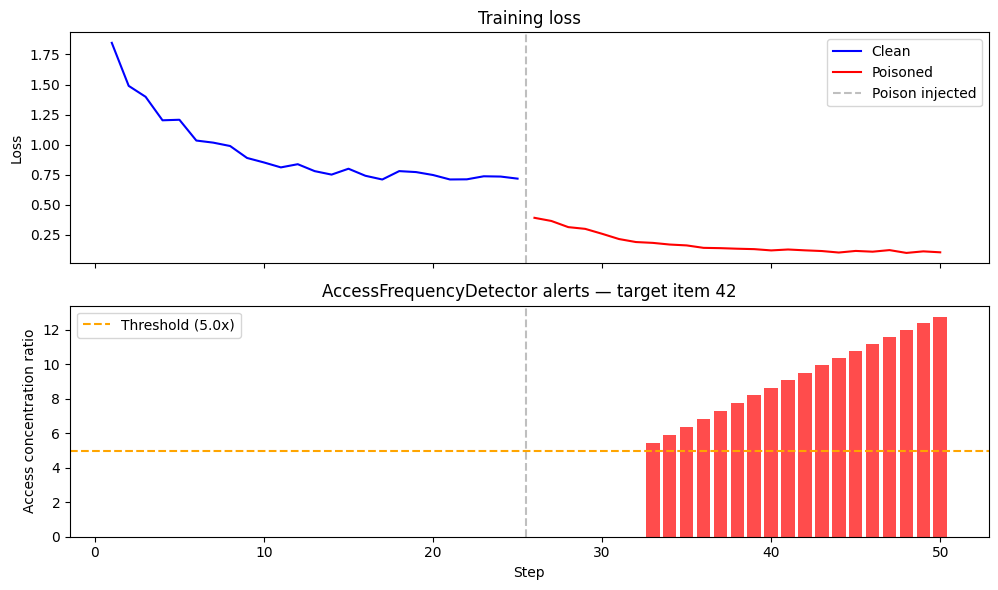

Saved demo_plot.png


In [5]:
import matplotlib.pyplot as plt

steps = list(range(1, 51))
losses = clean_losses + poison_losses
alert_steps = [a.step for a in all_alerts]
alert_ratios = [a.details["concentration_ratio"] for a in all_alerts]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Loss plot
ax1.plot(steps[:25], clean_losses, "b-", label="Clean")
ax1.plot(steps[25:], poison_losses, "r-", label="Poisoned")
ax1.axvline(x=25.5, color="gray", linestyle="--", alpha=0.5, label="Poison injected")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.set_title("Training loss")

# Alert plot
ax2.bar(alert_steps, alert_ratios, color="red", alpha=0.7, width=0.8)
ax2.axhline(y=5.0, color="orange", linestyle="--", label="Threshold (5.0x)")
ax2.axvline(x=25.5, color="gray", linestyle="--", alpha=0.5)
ax2.set_xlabel("Step")
ax2.set_ylabel("Access concentration ratio")
ax2.legend()
ax2.set_title(f"AccessFrequencyDetector alerts — target item {TARGET_ITEM}")

plt.tight_layout()
plt.savefig("demo_plot.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved demo_plot.png")

## Log file output

In [6]:
import json

guard.detach()

with open("demo_log.jsonl") as f:
    lines = f.readlines()

print(f"Total log lines: {len(lines)}")
print(f"Stats lines: {sum(1 for l in lines if '"stats"' in l)}")
print(f"Alert lines: {sum(1 for l in lines if '"alert"' in l)}")
print()

# Show first stats line and first alert line
for line in lines:
    obj = json.loads(line)
    if obj["type"] == "stats":
        print("Stats sample:")
        print(json.dumps(obj, indent=2))
        break

print()
for line in lines:
    obj = json.loads(line)
    if obj["type"] == "alert":
        print("Alert sample:")
        print(json.dumps(obj, indent=2))
        break

os.remove("demo_log.jsonl")

Total log lines: 118
Stats lines: 100
Alert lines: 18

Stats sample:
{
  "type": "stats",
  "step": 1,
  "table": "t_user_id",
  "data": {
    "n_accessed": 116.0,
    "grad_norm": 0.08871066570281982,
    "grad_max": 0.009111928753554821
  }
}

Alert sample:
{
  "type": "alert",
  "step": 33,
  "detector": "access_frequency",
  "severity": "warning",
  "table": "t_item_id",
  "message": "Row 42 accessed 5.5x above mean (count=11, mean=2.0)",
  "details": {
    "concentration_ratio": 5.460240963855421,
    "hottest_row": 42,
    "hottest_count": 11,
    "mean_count": 2.0145631067961167
  },
  "timestamp": 1771662847.1231391
}


## Summary

EmbdGuard detected the poisoning attack within **8 steps** of injection. The `AccessFrequencyDetector` caught item 42's access count spiking to >5x the mean, escalating to >12x by the end of the poisoned training.